# Churn Feature Engineering

## Objective

Create the information a churn model is allowed to use at each historical monthly snapshot.

The target was fixed in Notebook 02:

- look back **180 days** to identify an actionable customer;
- make a prediction at the monthly snapshot;
- label the customer churned when there is no retained purchase in the following **90 days**.

The central safety rule is: **the past creates features; the future creates only the answer (`Churn`)**.

## Data flow

```text
Raw transaction lines
        ↓
Shared cleaning rules
        ↓
FIFO reconciliation using only events before each snapshot
        ↓
30/60/90/180-day customer features
        +
90-day future churn label from Notebook 02
        ↓
churn_training_table.csv
```

A later cancellation cannot revise an earlier snapshot. For example, a cancellation recorded in May cannot change features calculated for 1 April.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# Locate the repository whether the notebook is opened from the root
# folder or from inside /notebooks.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from customer_intelligence.segmentation.viz import apply_style, style_ax

apply_style()
sns.set_context("notebook")

BLUE = "#2A78D6"
ORANGE = "#EB6834"
GREEN = "#54A24B"
RED = "#E45756"

TRAINING_PATH = (
    PROJECT_ROOT / "data" / "processed" / "churn_training_table.csv"
)

## Load the customer-snapshot table

One row represents one customer at one historical prediction date. The same customer can appear in several months because their behaviour changes over time.

In [2]:
training_df = pd.read_csv(
    TRAINING_PATH,
    parse_dates=["SnapshotDate"],
)

print(f"Customer-snapshot rows: {len(training_df):,}")
print(f"Columns: {training_df.shape[1]:,}")
print(f"Unique customers: {training_df['Customer ID'].nunique():,}")
print(f"Monthly snapshots: {training_df['SnapshotDate'].nunique()}")
print(
    "Snapshot period:",
    training_df['SnapshotDate'].min().date(),
    "to",
    training_df['SnapshotDate'].max().date(),
)

display(training_df.head())

Customer-snapshot rows: 47,821
Columns: 46
Unique customers: 5,204
Monthly snapshots: 16
Snapshot period: 2010-06-01 to 2011-09-01


,Customer ID,SnapshotDate,Churn,Recency,TenureDays,LifetimePurchaseDays,LifetimeOrders,LifetimeMonetary,LifetimeUnits,LifetimeUniqueProducts,...,PurchaseGapStd,HasRepeatPurchaseHistory,SnapshotMonth,SnapshotQuarter,IsHolidaySeason,CancellationRows180D,CancelledUnits180D,CancellationValue180D,PositiveUnits180D,CancellationUnitRate180D
0,12346,2010-06-01,0,91,91,1,1,27.05,5,5,...,NaN,0,6,2,0,0,0,0.00,5,0.000000
1,12349,2010-06-01,1,33,33,1,1,1068.52,473,46,...,NaN,0,6,2,0,5,5,24.15,473,0.010571
2,12355,2010-06-01,1,11,11,1,1,488.21,303,22,...,NaN,0,6,2,0,0,0,0.00,303,0.000000
3,12358,2010-06-01,0,175,175,1,1,1429.83,309,17,...,NaN,0,6,2,0,0,0,0.00,309,0.000000
4,12359,2010-06-01,0,70,178,4,4,1428.23,561,63,...,32.567878,1,6,2,0,4,216,94.00,777,0.277992


## What the features mean

| Feature family | Plain-language meaning | Examples |
|---|---|---|
| Recency | How long the customer has already been inactive | `Recency` |
| Rolling activity | Purchases made during recent periods | `Orders30D`, `Orders90D`, `Monetary180D` |
| Behaviour change | Whether recent activity is rising or falling | `OrderChange90D`, `MonetaryChange90D` |
| Lifetime relationship | Behaviour known over all history before the snapshot | `TenureDays`, `LifetimeOrders` |
| Purchase cadence | The customer's usual time between purchase days | `MedianPurchaseGap`, `LatestPurchaseGap` |
| Calendar context | When the prediction is being made | `SnapshotMonth`, `IsHolidaySeason` |
| Cancellation behaviour | Returns/cancellations already observed | `CancelledUnits180D`, `CancellationUnitRate180D` |

`Customer ID` identifies the row but is not a behavioural feature. `Churn` is the future answer and is never included in the predictor matrix.

## Data-contract and leakage checks

These checks stop the notebook immediately if the table contains duplicates, impossible time values or future information.

In [3]:
FUTURE_ONLY_COLUMNS = {
    "NextPurchaseDate",
    "DaysToNextPurchase",
    "LabelEndDate",
    "ReturnedWithinHorizon",
}

assert not FUTURE_ONLY_COLUMNS.intersection(training_df.columns)
assert not training_df[["Customer ID", "SnapshotDate"]].duplicated().any()
assert training_df["Churn"].isin([0, 1]).all()
assert training_df["Recency"].between(1, 180).all()
assert (training_df["Orders180D"] >= 1).all()
assert (training_df["Monetary180D"] >= 0).all()

# A longer window must contain at least as much observed activity as a
# shorter window for the same customer and snapshot.
for prefix in ["Orders", "PurchaseDays", "Monetary", "Units"]:
    columns = [f"{prefix}{days}D" for days in [30, 60, 90, 180]]
    increases = training_df[columns].diff(axis=1).iloc[:, 1:]
    assert (increases >= -1e-9).all().all()

print("All feature-table and leakage checks passed.")

All feature-table and leakage checks passed.


## Missing purchase-gap values are meaningful

A customer needs at least two purchase days before a gap can be calculated. Missing cadence values therefore mean **insufficient repeat-purchase history**, not corrupted data.

The model-preparation pipeline will retain `HasRepeatPurchaseHistory` and impute the numeric gap fields inside the training pipeline. Imputation must be fitted on training data only.

In [4]:
missing_summary = (
    training_df.isna().sum()
    .loc[lambda s: s > 0]
    .rename("MissingRows")
    .to_frame()
)
missing_summary["MissingShare"] = (
    missing_summary["MissingRows"] / len(training_df)
)

display(
    missing_summary.style.format({
        "MissingRows": "{:,}",
        "MissingShare": "{:.1%}",
    })
)

assert (
    training_df.loc[
        training_df["HasRepeatPurchaseHistory"] == 0,
        "MedianPurchaseGap",
    ].isna().all()
)

,MissingRows,MissingShare
MedianPurchaseGap,"12,755",26.7%
LatestPurchaseGap,"12,755",26.7%
PurchaseGapStd,"12,755",26.7%


## Target balance

Target balance tells us how many historical examples returned versus remained inactive. This is not model accuracy; no model has been trained yet.

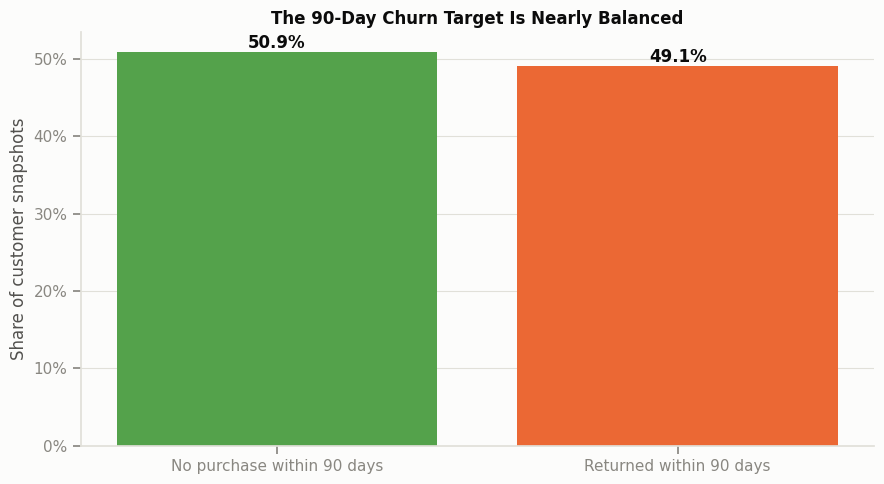

In [5]:
target_summary = (
    training_df["Churn"]
    .map({0: "Returned within 90 days", 1: "No purchase within 90 days"})
    .value_counts()
    .rename_axis("Outcome")
    .reset_index(name="CustomerSnapshots")
)
target_summary["Share"] = (
    target_summary["CustomerSnapshots"] / len(training_df)
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    target_summary["Outcome"],
    target_summary["Share"],
    color=[GREEN, ORANGE],
)
for bar, share in zip(bars, target_summary["Share"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{share:.1%}",
        ha="center",
        va="bottom",
        weight="bold",
    )
ax.set_title("The 90-Day Churn Target Is Nearly Balanced", weight="bold")
ax.set_xlabel("")
ax.set_ylabel("Share of customer snapshots")
ax.yaxis.set_major_formatter(PercentFormatter(1))
style_ax(ax)
plt.tight_layout()
plt.show()

## First behavioural comparison

This is a descriptive comparison, not proof of causation. It checks whether the features move in sensible directions before modelling.

In [6]:
behaviour_summary = (
    training_df
    .groupby("Churn")[[
        "Recency",
        "Orders90D",
        "Monetary90D",
        "LifetimeOrders",
        "MedianPurchaseGap",
    ]]
    .median()
    .rename(index={0: "Returned", 1: "Churned"})
)

display(behaviour_summary.round(1))

,Recency,Orders90D,Monetary90D,LifetimeOrders,MedianPurchaseGap
Churn,,,,,
Returned,37.0,1.0,413.2,5.0,43.0
Churned,73.0,1.0,137.7,2.0,75.5


The expected pattern is visible if churned customers are typically less recent, purchase less, spend less and have longer gaps. This is a sanity check; chronological validation will determine whether the patterns predict genuinely later outcomes.

## Stability across monthly snapshots

The retailer is seasonal, so churn prevalence can change by month. This is why the future model must be evaluated chronologically instead of randomly mixing months.

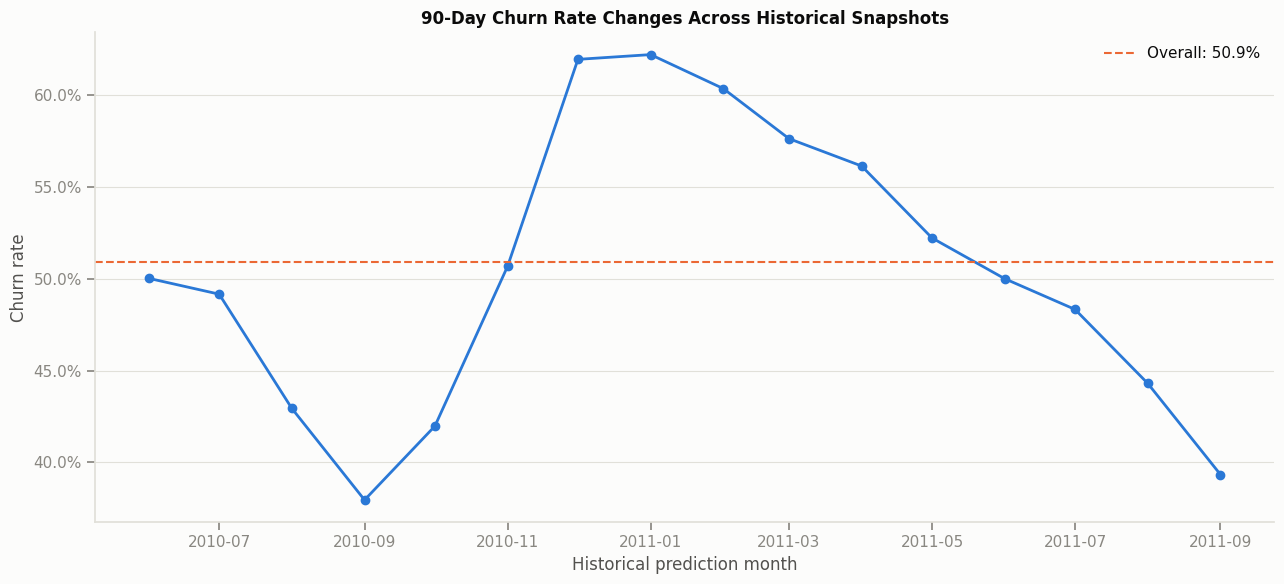

In [7]:
snapshot_summary = (
    training_df
    .groupby("SnapshotDate", as_index=False)
    .agg(
        EligibleCustomers=("Customer ID", "nunique"),
        ChurnRate=("Churn", "mean"),
    )
)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(
    snapshot_summary["SnapshotDate"],
    snapshot_summary["ChurnRate"],
    color=BLUE,
    marker="o",
    linewidth=2,
)
ax.axhline(
    training_df["Churn"].mean(),
    color=ORANGE,
    linestyle="--",
    label=f"Overall: {training_df['Churn'].mean():.1%}",
)
ax.set_title("90-Day Churn Rate Changes Across Historical Snapshots", weight="bold")
ax.set_xlabel("Historical prediction month")
ax.set_ylabel("Churn rate")
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend(frameon=False)
style_ax(ax)
plt.tight_layout()
plt.show()

## Define modelling columns safely

This final cell records what is an identifier, what is the target and what may become a predictor. Transformations and imputation will be fitted later using training dates only.

In [8]:
IDENTIFIER_COLUMNS = ["Customer ID", "SnapshotDate"]
TARGET_COLUMN = "Churn"

feature_columns = [
    column
    for column in training_df.columns
    if column not in IDENTIFIER_COLUMNS + [TARGET_COLUMN]
]

assert TARGET_COLUMN not in feature_columns
assert not FUTURE_ONLY_COLUMNS.intersection(feature_columns)

print(f"Candidate model features: {len(feature_columns)}")
print(feature_columns)

Candidate model features: 43
['Recency', 'TenureDays', 'LifetimePurchaseDays', 'LifetimeOrders', 'LifetimeMonetary', 'LifetimeUnits', 'LifetimeUniqueProducts', 'AverageOrderValue', 'PurchaseDays30D', 'Orders30D', 'Monetary30D', 'Units30D', 'PurchaseDays60D', 'Orders60D', 'Monetary60D', 'Units60D', 'PurchaseDays90D', 'Orders90D', 'Monetary90D', 'Units90D', 'PurchaseDays180D', 'Orders180D', 'Monetary180D', 'Units180D', 'OrdersPrevious90D', 'MonetaryPrevious90D', 'PurchaseDaysPrevious90D', 'OrderChange90D', 'MonetaryChange90D', 'OrderTrendRatio90D', 'MonetaryTrendRatio90D', 'MedianPurchaseGap', 'LatestPurchaseGap', 'PurchaseGapStd', 'HasRepeatPurchaseHistory', 'SnapshotMonth', 'SnapshotQuarter', 'IsHolidaySeason', 'CancellationRows180D', 'CancelledUnits180D', 'CancellationValue180D', 'PositiveUnits180D', 'CancellationUnitRate180D']


## Feature-engineering conclusion

The modelling table contains **47,821 customer-month observations**, **5,204 customers**, **16 monthly snapshots** and a **50.9% churn rate**.

The table is leakage-safe by construction: FIFO cancellation state is frozen using only transactions observed before each snapshot, while the future contributes only the `Churn` target. Missing cadence values identify customers without two purchase days and will be handled inside the later modelling pipeline.

The next stage is to define a purged chronological train/validation/test split, establish a simple Recency-rule baseline, and then compare logistic regression with tree-based models.